<b style="color: black;">Step 1: Imports & helper functions from main file</b>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import tensorflow as tf
from tensorflow import keras


# Make plots a bit bigger and prettier
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)

# Ensure figures folder exists
os.makedirs("figures", exist_ok=True)

# Import helper functions from your main script
from rossmann_dnn import (
    add_date_features,
    add_competition_features,
    add_promo2_features,
    add_lag_features,
    add_store_aggregate_features,
    build_dnn,
    rmspe_numpy,
    set_seeds,
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("Imports OK")


Imports OK


<b style="color: black;">Step 2: Load data & feature engineering</b>

In [35]:
data_dir = "data"
train_path = os.path.join(data_dir, "train.csv")
test_path = os.path.join(data_dir, "test.csv")
store_path = os.path.join(data_dir, "store.csv")

print("Loading data...")
train = pd.read_csv(train_path, low_memory=False)
test = pd.read_csv(test_path)
store = pd.read_csv(store_path)

# Match your script's preprocessing
train["StateHoliday"] = train["StateHoliday"].astype(str)
test["StateHoliday"] = test["StateHoliday"].astype(str)

train = pd.merge(train, store, on="Store", how="left")
test = pd.merge(test, store, on="Store", how="left")

test["Open"] = test["Open"].fillna(1)

print("Adding date features...")
train = add_date_features(train)
test = add_date_features(test)

print("Adding competition features...")
train = add_competition_features(train)
test = add_competition_features(test)

print("Adding Promo2 features...")
train = add_promo2_features(train)
test = add_promo2_features(test)

print("Adding lag features...")
train = add_lag_features(train)

# Drop Customers (not in test)
if "Customers" in train.columns:
    train = train.drop(columns=["Customers"])

# Filter: open days with positive sales
train = train[(train["Open"] == 1) & (train["Sales"] > 0)].copy()

# Fill remaining NaNs in lag features with column medians
lag_cols = [
    "Sales_lag_1",
    "Sales_lag_7",
    "Sales_lag_14",
    "Sales_rollmean_7",
    "Sales_rollmean_30",
]
lag_medians = train[lag_cols].median()
train[lag_cols] = train[lag_cols].fillna(lag_medians)

print("Adding store aggregate features...")
train, test = add_store_aggregate_features(train, test)

# For test, approximate lag features using StoreAvgSales
for col in lag_cols:
    if col not in test.columns:
        test[col] = np.nan
    test[col] = test[col].fillna(test["StoreAvgSales"])

print("Train shape after processing:", train.shape)
train.head()


Loading data...
Adding date features...
Adding competition features...
Adding Promo2 features...
Adding lag features...
Adding store aggregate features...
Train shape after processing: (844338, 33)


,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,Promo2OpenWeeks,IsPromoMonth,Sales_lag_1,Sales_lag_7,Sales_lag_14,Sales_rollmean_7,Sales_rollmean_30,StoreAvgSales,StoreMedianSales,StoreDowAvgSales
0,1,3,2013-01-02,5530,1,0,0,1,c,a,...,0,0,0.0,6224.0,6239.0,0.000000,0.000000,4759.096031,4647.0,4555.712121
1,1,4,2013-01-03,4327,1,0,0,1,c,a,...,0,0,5530.0,6224.0,6239.0,2765.000000,2765.000000,4759.096031,4647.0,4457.838710
2,1,5,2013-01-04,4486,1,0,0,1,c,a,...,0,0,4327.0,6224.0,6239.0,3285.666667,3285.666667,4759.096031,4647.0,4726.480620
3,1,6,2013-01-05,4997,1,0,0,1,c,a,...,0,0,4486.0,6224.0,6239.0,3585.750000,3585.750000,4759.096031,4647.0,4942.970149
4,1,1,2013-01-07,7176,1,1,0,1,c,a,...,0,0,0.0,6224.0,6239.0,3223.333333,3223.333333,4759.096031,4647.0,5177.968750


<b style="color: black;">Figure 1: Total sales over time (for all stores)</b>

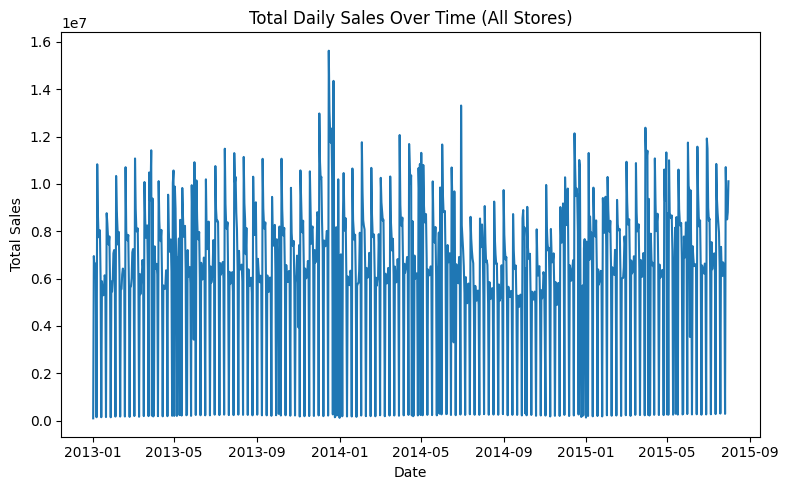

In [51]:
sales_by_date = (
    train_open.groupby("Date")["Sales"]
    .sum()
    .sort_index()
)

plt.figure()
plt.plot(sales_by_date.index, sales_by_date.values)
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Total Daily Sales Over Time (All Stores)")
plt.tight_layout()
plt.savefig("figures/1_total_sales_over_time.png", dpi=300)
plt.show()

<b style="color: black;">Figure 2: Average sales by day of week</b>

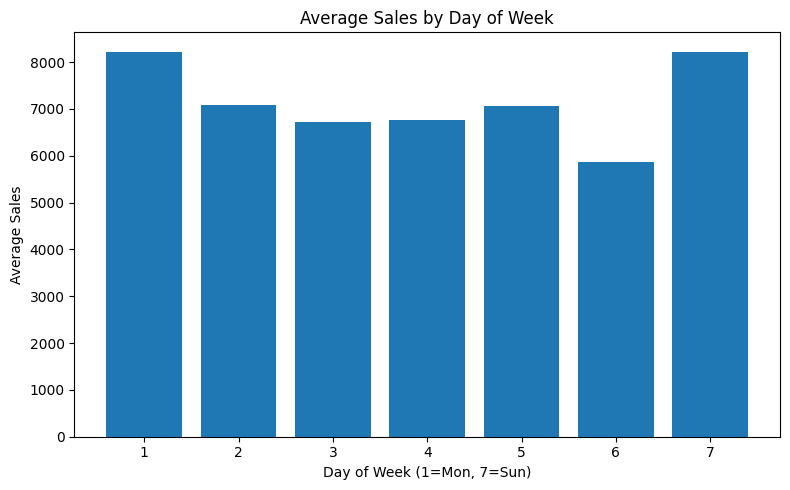

In [54]:
dow_mean = (
    train_open.groupby("DayOfWeek")["Sales"]
    .mean()
    .sort_index()
)

plt.figure()
plt.bar(dow_mean.index.astype(str), dow_mean.values)
plt.xlabel("Day of Week (1=Mon, 7=Sun)")
plt.ylabel("Average Sales")
plt.title("Average Sales by Day of Week")
plt.tight_layout()
plt.savefig("figures/2_avg_sales_by_dow.png", dpi=300)
plt.show()

<b style="color: black;">Figure 3: Average sales by month</b>

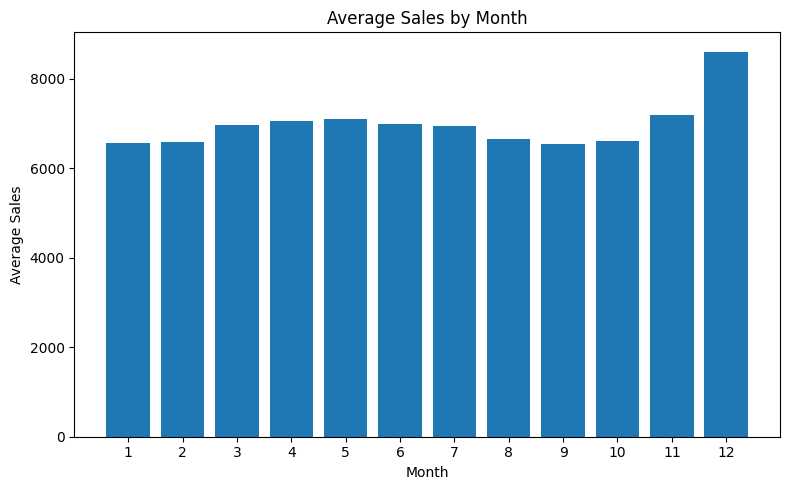

In [55]:
month_mean = (
    train_open.groupby("Month")["Sales"]
    .mean()
    .sort_index()
)

plt.figure()
plt.bar(month_mean.index.astype(str), month_mean.values)
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.title("Average Sales by Month")
plt.tight_layout()
plt.savefig("figures/3_avg_sales_by_month.png", dpi=300)
plt.show()

<b style="color: black;">Figure 4: Promo effect</b>

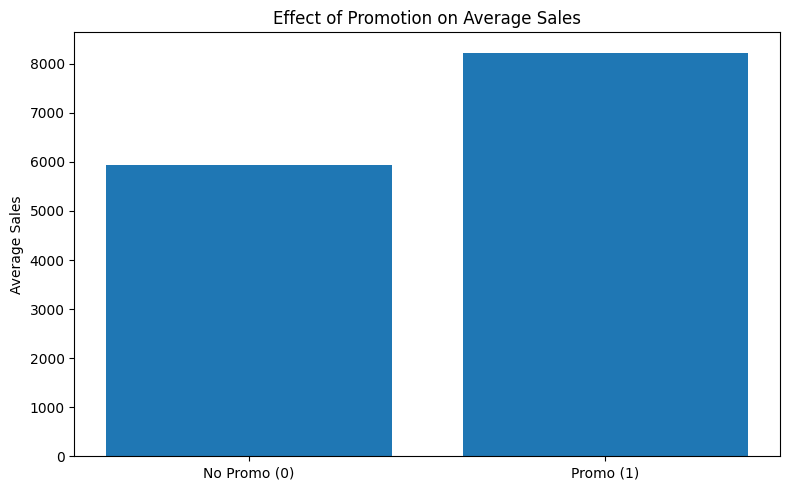

In [58]:
promo_mean = (
    train_open.groupby("Promo")["Sales"]
    .mean()
    .sort_index()
)

labels = ["No Promo (0)", "Promo (1)"]
plt.figure()
plt.bar(labels, promo_mean.values)
plt.ylabel("Average Sales")
plt.title("Effect of Promotion on Average Sales")
plt.tight_layout()
plt.savefig("figures/4_promo_effect.png", dpi=300)
plt.show()

<b style="color: black;">Figure 5: Distribution of competition distance</b>

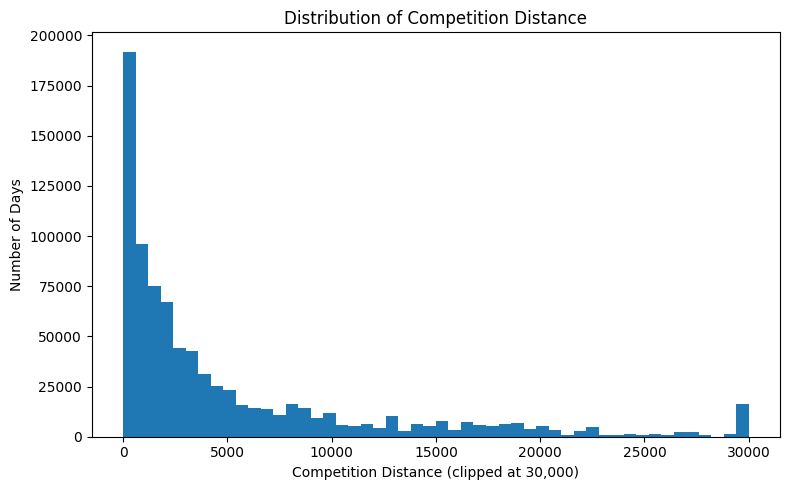

In [59]:
plt.figure()
# clip huge distances for nicer plot
dist = train_open["CompetitionDistance"].clip(upper=30000)
plt.hist(dist, bins=50)
plt.xlabel("Competition Distance (clipped at 30,000)")
plt.ylabel("Number of Days")
plt.title("Distribution of Competition Distance")
plt.tight_layout()
plt.savefig("figures/5_competition_distance_hist.png", dpi=300)
plt.show()


<b style="color: black;">Figure 6: Sales distribution</b>

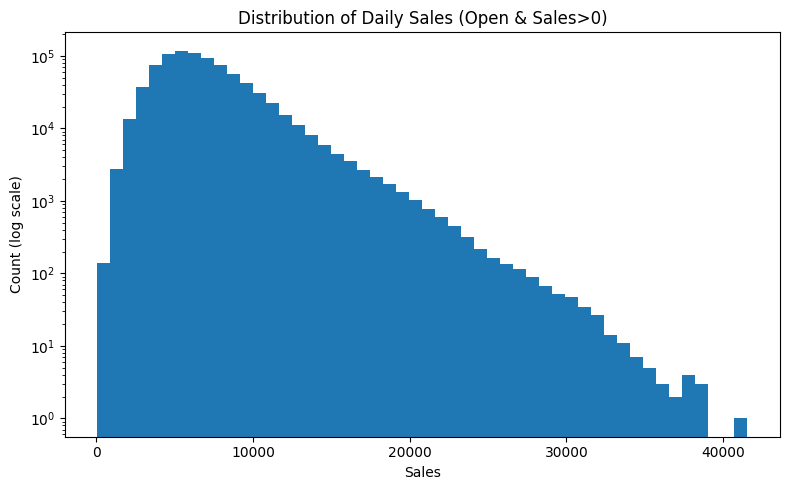

In [61]:
plt.figure()
plt.hist(train_open["Sales"], bins=50)
plt.yscale("log")
plt.xlabel("Sales")
plt.ylabel("Count (log scale)")
plt.title("Distribution of Daily Sales (Open & Sales>0)")
plt.tight_layout()
plt.savefig("figures/6_sales_distribution_log.png", dpi=300)
plt.show()

<b style="color: black;">Figure 7: Predicted vs actual sales</b>

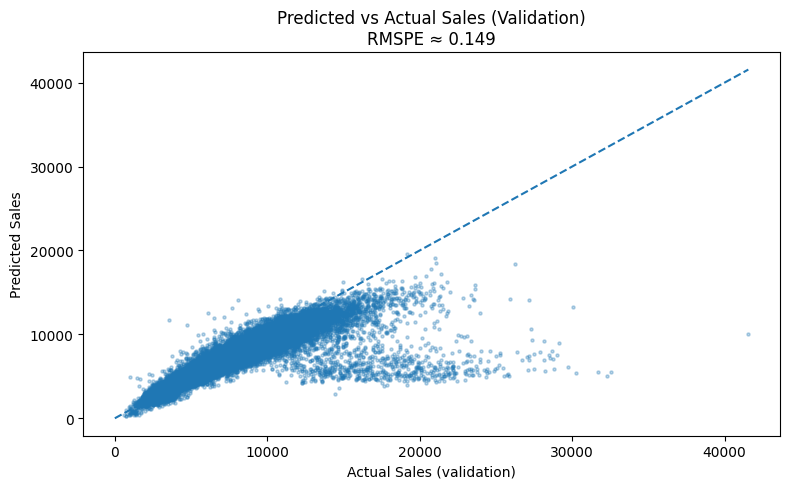

In [70]:
os.makedirs("figures", exist_ok=True)

y_val_actual = np.expm1(y_val)
y_val_pred   = np.expm1(val_pred_log)

plt.scatter(y_val_actual, y_val_pred, alpha=0.3, s=5)
plt.xlabel("Actual Sales (validation)")
plt.ylabel("Predicted Sales")
plt.title(f"Predicted vs Actual Sales (Validation)\nRMSPE ≈ {val_rmspe:.3f}")

max_val = max(y_val_actual.max(), y_val_pred.max())
plt.plot([0, max_val], [0, max_val], linestyle="--")
plt.tight_layout()
plt.savefig("figures/7_pred_vs_actual_val.png", dpi=300)
plt.show()

<b style="color: black;">Figure 8: Example store – time series of actual vs predicted</b>

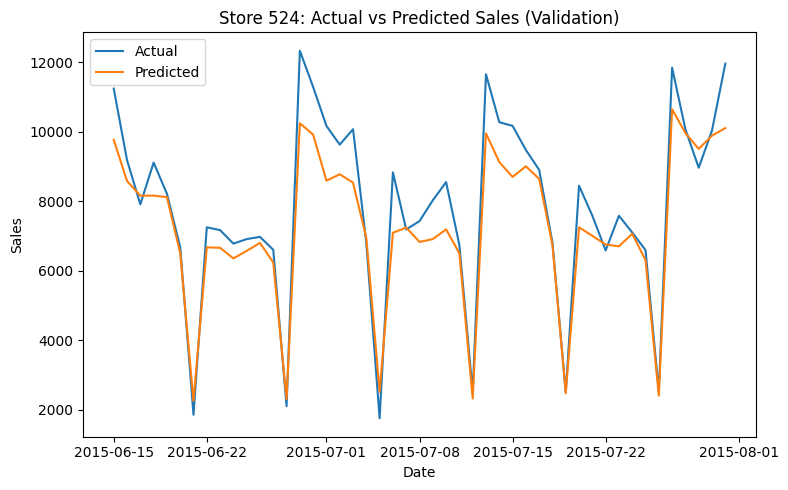

In [71]:
val_results["SalesActual"] = y_val_actual
val_results["SalesPred"]   = y_val_pred

store_id = val_results["Store"].value_counts().idxmax()
store_series = (
    val_results[val_results["Store"] == store_id]
    .sort_values("Date")
)

plt.plot(store_series["Date"], store_series["SalesActual"], label="Actual")
plt.plot(store_series["Date"], store_series["SalesPred"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title(f"Store {store_id}: Actual vs Predicted Sales (Validation)")
plt.legend()
plt.tight_layout()
plt.savefig(f"figures/8_store_{store_id}_val_actual_vs_pred.png", dpi=300)
plt.show()